# SAXS NAF Benchmark

Compares NAF against mumott baselines (SH, GK, FBP) across the partial datasets
available for a given `DATASET` entry in the registry.

**Design**
- Ground truth: mumott SH or GK reconstruction on `combined_dc` (flag: `GT_METHOD`);
  falls back to the dataset's own `get_ground_truth()` when no `combined_dc` is
  available (e.g. `fiber-synthetic`, where the ground truth is exact by
  construction), and only falls back further to `mumott_gk` as a pseudo-GT if
  neither is available.
- Partial datasets: all non-`combined` DC types exposed by the dataset object
- Metrics: RSM Pearson correlation (bucketed by missing-arc), orientation angular
  error (RA-weighted), RA MAE, fiber symmetry MAE, PSNR/SSIM/NRMSE, held-out NRMSE
- Reconstructions cached as `{name}_{hash8}.npy` + JSON sidecar

In [1]:
import sys
sys.path.insert(0, '/myhome/smartt')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mumott.methods.basis_sets import SphericalHarmonics, GaussianKernels
from mumott.methods.projectors import SAXSProjector
from mumott.methods.residual_calculators import GradientResidualCalculator
from mumott.optimization.loss_functions import SquaredLoss
from mumott.optimization.optimizers import LBFGS
from mumott.optimization.regularizers import Laplacian

from smartt.data_containers import get_dataset, REGISTRY
from smartt.saxs_naf import saxs_naf_reconstruction
from smartt.saxs_naf.cache import (
    save_recon, load_recon, list_cache, save_metrics, load_metrics,
    cache_table, CacheChooser, project_params,
)
from smartt.saxs_naf.metrics import (
    split_holdout, to_sh_coefficients, fbp_to_sh,
    compute_ground_truth, compute_metrics, metrics_table
)
from smartt.saxs_fbp.reconstruction import saxs_fbp_reconstruction
from smartt.saxs_naf.eval import plot_rsm_direction, evaluate_models

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


## Parameters
Edit this cell to change the run configuration.

In [2]:
DATASET  = 'nielsen-mammoth'    # one of: b411, zenodo, frogbone, fiber-synthetic

# Shared / evaluation
ELL_MAX      = 8
K_DIRS       = 30
ALPHA_DEG    = 45    # sample tilt angle for RSM evaluation (b411/zenodo: 45)
HALF_SPACE   = 'y'
HOLDOUT_FRAC = 0.0
HOLDOUT_SEED = 42

# Ground-truth (combined DC)
GT_METHOD = 'gk'     # 'sh' or 'gk'
GT_PARAMS = dict(
    gt_method        = GT_METHOD,
    ell_max          = ELL_MAX,
    n_iterations     = 20,
    laplacian_weight = 1e-1,
    maxcor           = 5,
)

# Mumott LBFGS baselines (shared by mumott_sh and mumott_gk)
MUMOTT_PARAMS = dict(
    ell_max          = 8,
    mumott_iters     = 20,
    laplacian_weight = 1e-1,
    # scipy L-BFGS-B uses 32-bit ints for wa_size=(2*maxcor+5)*n;
    # at n~100M, maxcor>=9 overflows INT32_MAX -> segfault.
    maxcor           = 5,
)

# NAF
NAF_PARAMS = dict(
    ell_max       = ELL_MAX,
    n_iterations  = 1200,
    lr            = 0.002,
    batch_size    = 100,
    reg_weight_sh = 1e-6,
    reg_weight_tv = 5e-6,
)

FORCE_RECOMPUTE = False

## 1. Load dataset from registry

In [3]:
ds        = get_dataset(DATASET)
cache_dir = ds.get_cache_dir()

print(f'Dataset  : {ds.name}')
print(f'DC types : {ds.available_dc_types()}')
print(f'Cache    : {cache_dir}')

Dataset  : nielsen-mammoth
DC types : ['main']
Cache    : /myhome/data/smartt/shared/nielsen_synthetic/recon_cache/mammoth_1.0e+02


## 1b. Load params from the cache (optional)

Browse everything already computed in `cache_dir`, grouped by method. Pick a
`dc_type` at the top, then select a row per method (or leave *none* to keep the
value from the **Parameters** cell). Click **Load**, then **re-run the adapter
cell below plus everything downstream** — the selected params overwrite
`NAF_PARAMS` / `MUMOTT_PARAMS` / `GT_PARAMS`, guaranteeing a cache hit.

In [ ]:
chooser = CacheChooser(cache_dir)
chooser

In [5]:
# Apply the chooser selection to the param dicts. Safe to run even if you never
# opened the chooser (falls back to the Parameters cell). Re-run this cell and
# everything below after clicking Load.
if 'chooser' in globals() and getattr(chooser, 'selection', None):
    sel = chooser.selection
    if 'naf' in sel:
        NAF_PARAMS.update(project_params(sel['naf'], NAF_PARAMS))
    for _m in ('mumott_sh', 'mumott_gk'):          # both share MUMOTT_PARAMS
        if _m in sel:
            MUMOTT_PARAMS.update(project_params(sel[_m], MUMOTT_PARAMS))
    if 'ground_truth' in sel:
        GT_PARAMS.update(project_params(sel['ground_truth'], GT_PARAMS))
        GT_METHOD = GT_PARAMS['gt_method']
    print('Loaded from chooser:')
    print('  NAF_PARAMS   :', NAF_PARAMS)
    print('  MUMOTT_PARAMS:', MUMOTT_PARAMS)
    print('  GT_PARAMS    :', GT_PARAMS)
else:
    print('No chooser selection — using params from the Parameters cell.')

Loaded from chooser:
  NAF_PARAMS   : {'ell_max': 8, 'n_iterations': 2000, 'lr': 0.0005, 'batch_size': 100, 'reg_weight_sh': 0.0, 'reg_weight_tv': 0.0}
  MUMOTT_PARAMS: {'ell_max': 8, 'mumott_iters': 20, 'laplacian_weight': 0.1, 'maxcor': 5}
  GT_PARAMS    : {'gt_method': 'gk', 'ell_max': 8, 'n_iterations': 20, 'laplacian_weight': 0.1, 'maxcor': 5}


In [6]:
partial_types = [t for t in ds.available_dc_types() if t != 'combined']
partial_dcs   = {t: ds.get_dc(t) for t in partial_types}
combined_dc   = ds.get_combined_dc() if ds.has_combined else None

for t, dc in partial_dcs.items():
    print(f"{t:12s}  {len(dc.projections):4d} projections  vol={tuple(dc.geometry.volume_shape)}")
if combined_dc is not None:
    print(f"{'combined':12s}  {len(combined_dc.projections):4d} projections  vol={tuple(combined_dc.geometry.volume_shape)}")

INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.


/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:228: DeprecationWarning: Entry name rotations is deprecated. Use inner_angle instead.
  _deprecated_key_warning('rotations')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:237: DeprecationWarning: Entry name tilts is deprecated. Use outer_angle instead.
  _deprecated_key_warning('tilts')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:269: DeprecationWarning: Entry name offset_j is deprecated. Use j_offset instead.
  _deprecated_key_warning('offset_j')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:279: DeprecationWarning: Entry name offset_k is deprecated. Use k_offset instead.
  _deprecated_key_warning('offset_k')


INFO:No sample geometry information was found. Default mumott geometry assumed.
INFO:No detector geometry information was found. Default mumott geometry assumed.
main           417 projections  vol=(np.int64(60), np.int64(60), np.int64(80))


## 2. Holdout / validation split

The `holdout_nrmse` metric measures how well a reconstruction predicts **measured
projections it never trained on** — an independent, ground-truth-free consistency
check.

- **Remount present** (`main` + `remount`, e.g. b411/zenodo): the two mountings are
  independent measurements of the *same* sample sharing one volume frame (they are
  index-splits of the combined DC), so each mount's reconstruction is validated
  against the **other mount's full set** of measured projections. This costs no
  training data and gives a much larger, genuinely independent validation set.
- **No remount** (frogbone, fiber-synthetic, …): fall back to `split_holdout`, which
  leaves a `HOLDOUT_FRAC` slice of projections out of training to serve as the
  validation set.

Training itself is unchanged in both cases (still built from `split_holdout`), so
cached reconstructions remain valid — only the *validation target* differs.

In [7]:
# When both mounts are present we validate each mount against the *other* mount's
# full, independent measurement set instead of holding projections out of training.
# The training set is still built from split_holdout (so cached reconstructions stay
# valid); only `held_dcs` — the target for the holdout_nrmse metric — changes.
CROSS_MOUNT = {'main', 'remount'}.issubset(set(partial_types))

train_dcs = {}
held_dcs  = {}
for dc_type, dc in partial_dcs.items():
    train_dcs[dc_type], split_held = split_holdout(dc, fraction=HOLDOUT_FRAC, seed=HOLDOUT_SEED)
    if CROSS_MOUNT:
        other = 'remount' if dc_type == 'main' else 'main'
        held_dcs[dc_type] = partial_dcs[other]   # full other-mount DC as validation set
        src = f'cross-mount vs {other}'
    else:
        held_dcs[dc_type] = split_held
        src = 'split-holdout'
    print(f'{dc_type:12s}  train={len(train_dcs[dc_type].projections):4d}  '
          f'held={len(held_dcs[dc_type].projections):4d}  ({src})')

main          train= 416  held=   1  (split-holdout)


## 3. Baselines
All methods are run for every partial DC type (e.g. `main`, `remount`).

In [8]:
def _mumott_cache_params(method, dc_type):
    """Params dict matching reconstruct_job.py _mumott_params exactly."""
    return dict(
        method=method,
        dataset=ds.name,
        dc_type=dc_type,
        ell_max=MUMOTT_PARAMS['ell_max'],
        mumott_iters=MUMOTT_PARAMS['mumott_iters'],
        laplacian_weight=MUMOTT_PARAMS['laplacian_weight'],
        maxcor=MUMOTT_PARAMS['maxcor'],
        holdout_frac=HOLDOUT_FRAC,
        holdout_seed=HOLDOUT_SEED,
    )


def _naf_cache_params(dc_type):
    """Params dict matching reconstruct_job.py _naf_params exactly."""
    return dict(
        method='naf',
        dataset=ds.name,
        dc_type=dc_type,
        ell_max=ELL_MAX,
        n_iterations=NAF_PARAMS['n_iterations'],
        lr=NAF_PARAMS['lr'],
        batch_size=NAF_PARAMS['batch_size'],
        reg_weight_sh=NAF_PARAMS['reg_weight_sh'],
        reg_weight_tv=NAF_PARAMS['reg_weight_tv'],
        holdout_frac=HOLDOUT_FRAC,
        holdout_seed=HOLDOUT_SEED,
    )


def _run_mumott_sh(train_dc, dc_type):
    params = _mumott_cache_params('mumott_sh', dc_type)
    name   = f'mumott_sh_{ds.name}_{dc_type}'
    cached = None if FORCE_RECOMPUTE else load_recon(cache_dir, name, params)
    if cached is not None:
        print(f'  [cache] mumott_sh  {dc_type}  {cached.shape}'); return cached
    projector = SAXSProjector(train_dc.geometry)
    basis = SphericalHarmonics(ell_max=MUMOTT_PARAMS['ell_max'],
                               probed_coordinates=train_dc.geometry.probed_coordinates)
    rc   = GradientResidualCalculator(data_container=train_dc, basis_set=basis, projector=projector)
    loss = SquaredLoss(residual_calculator=rc)
    loss.add_regularizer('laplacian', Laplacian(), regularization_weight=MUMOTT_PARAMS['laplacian_weight'])
    result = LBFGS(loss, maxiter=MUMOTT_PARAMS['mumott_iters'], maxcor=MUMOTT_PARAMS['maxcor']).optimize()['x'].astype('float32')
    save_recon(cache_dir, name, result, params)
    print(f'  [done ] mumott_sh  {dc_type}  {result.shape}')
    return result


def _run_mumott_gk(train_dc, dc_type):
    params = _mumott_cache_params('mumott_gk', dc_type)
    name   = f'mumott_gk_{ds.name}_{dc_type}'
    cached = None if FORCE_RECOMPUTE else load_recon(cache_dir, name, params)
    if cached is not None:
        print(f'  [cache] mumott_gk  {dc_type}  {cached.shape}'); return cached
    projector = SAXSProjector(train_dc.geometry)
    basis     = GaussianKernels(probed_coordinates=train_dc.geometry.probed_coordinates)
    rc   = GradientResidualCalculator(data_container=train_dc, basis_set=basis, projector=projector)
    loss = SquaredLoss(residual_calculator=rc)
    loss.add_regularizer('laplacian', Laplacian(), regularization_weight=MUMOTT_PARAMS['laplacian_weight'])
    result_gk = LBFGS(loss, maxiter=MUMOTT_PARAMS['mumott_iters'], maxcor=MUMOTT_PARAMS['maxcor']).optimize()
    result = to_sh_coefficients(basis, ell_max=ELL_MAX, coefficients=result_gk['x'])
    save_recon(cache_dir, name, result, params)
    print(f'  [done ] mumott_gk  {dc_type}  {result.shape}')
    return result


def _run_fbp(train_dc, dc_type):
    params = dict(method='fbp', dataset=ds.name, dc_type=dc_type, ell_max=ELL_MAX)
    name   = f'fbp_{ds.name}_{dc_type}'
    cached = None if FORCE_RECOMPUTE else load_recon(cache_dir, name, params)
    if cached is not None:
        print(f'  [cache] fbp  {dc_type}  {cached.shape}'); return cached
    res    = saxs_fbp_reconstruction(train_dc)
    result = fbp_to_sh(res[0].cpu().numpy(), res[1], ell_max=ELL_MAX)
    save_recon(cache_dir, name, result, params)
    print(f'  [done ] fbp  {dc_type}  {result.shape}')
    return result


def _run_naf(train_dc, dc_type):
    params = _naf_cache_params(dc_type)
    name   = f'naf_{ds.name}_{dc_type}'
    cached = None if FORCE_RECOMPUTE else load_recon(cache_dir, name, params)
    if cached is not None:
        print(f'  [cache] naf  {dc_type}  {cached.shape}'); return cached
    res    = saxs_naf_reconstruction(train_dc, **NAF_PARAMS)
    result = res['reconstruction'].numpy()
    save_recon(cache_dir, name, result, params)
    print(f'  [done ] naf  {dc_type}  {result.shape}')
    return result


all_coeffs = {}   # dc_type -> {method -> ndarray}
for dc_type in partial_types:
    print(f'\n── {dc_type} ──')
    all_coeffs[dc_type] = {
        'mumott_sh': _run_mumott_sh(train_dcs[dc_type], dc_type),
        'mumott_gk': _run_mumott_gk(train_dcs[dc_type], dc_type),
        'fbp':       _run_fbp(train_dcs[dc_type], dc_type),
        'naf':       _run_naf(train_dcs[dc_type], dc_type),
    }


── main ──
  [cache] mumott_sh  main  (60, 60, 80, 45)
  [cache] mumott_gk  main  (60, 60, 80, 45)
  [cache] fbp  main  (60, 60, 80, 45)
  [cache] naf  main  (60, 60, 80, 45)


## 4. Ground-truth reconstruction (combined dataset)

In [9]:
if combined_dc is not None:
    gt_params = dict(GT_PARAMS)
    coeffs_gt = None if FORCE_RECOMPUTE else load_recon(cache_dir, 'ground_truth', gt_params)
    if coeffs_gt is None:
        print('Running GT reconstruction…')
        print('NOTE: one forward pass takes ~2 min; expect ~80 min total. Run via')
        print('  python ../scripts/compute_benchmark_gt.py')
        print('to avoid kernel timeout, then re-run this cell to load from cache.')
        coeffs_gt = compute_ground_truth(combined_dc, **gt_params)
        save_recon(cache_dir, 'ground_truth', coeffs_gt, gt_params)
        print(f'Saved  shape={coeffs_gt.shape}')
    else:
        print(f'Loaded GT from cache  shape={coeffs_gt.shape}')
elif hasattr(ds, 'get_ground_truth'):
    # No combined DC, but the dataset carries an exact-by-construction ground
    # truth (e.g. fiber-synthetic) — use that instead of a pseudo-GT baseline.
    coeffs_gt = ds.get_ground_truth()
    print(f'No combined DC — using dataset-provided ground truth  shape={coeffs_gt.shape}')
else:
    coeffs_gt = all_coeffs['main']['mumott_gk']
    print('No combined DC and no dataset ground truth available — using mumott_gk as pseudo-GT.')

No combined DC — using dataset-provided ground truth  shape=(60, 60, 80, 45)


## 5. Metrics

In [10]:
metric_params = dict(
    dataset=DATASET,
    gt_method=GT_METHOD,
    ell_max=ELL_MAX,
    K=K_DIRS,
    half_space=HALF_SPACE,
    holdout_frac=HOLDOUT_FRAC,
    holdout_seed=HOLDOUT_SEED,
    # 'cross_mount' → holdout_nrmse validates against the other mount's full set;
    # 'split'       → against the split_holdout slice. Part of the key so the two
    # regimes never share a cached metrics entry.
    holdout_source='cross_mount' if CROSS_MOUNT else 'split',
    mumott_iters=MUMOTT_PARAMS['mumott_iters'],
    laplacian_weight=MUMOTT_PARAMS['laplacian_weight'],
    **{f'naf_{k}': v for k, v in NAF_PARAMS.items()},
)

metric_kw = dict(
    ground_truth=coeffs_gt,
    ell_max=ELL_MAX,
    K=K_DIRS,
    mask=None,          # None → auto-Otsu on GT c00
    half_space=HALF_SPACE,
    compute_orientation=True,
)

all_results = {}
for dc_type in partial_types:
    cached = None if FORCE_RECOMPUTE else load_metrics(cache_dir, dc_type, metric_params)
    if cached is not None:
        print(f'Loaded metrics for {dc_type} from cache.')
        all_results[dc_type] = cached
    else:
        print(f'Computing metrics for {dc_type}…')
        all_results[dc_type] = compute_metrics(
            reconstructions=all_coeffs[dc_type],
            dc=train_dcs[dc_type],
            held_out_dc=held_dcs[dc_type],
            **metric_kw,
        )
        save_metrics(cache_dir, dc_type, all_results[dc_type], metric_params)
        print(f'  saved.')
print('Done.')

Loaded metrics for main from cache.
Done.


## 6. Results tables

In [11]:
for dc_type in partial_types:
    print(f'=== {ds.name} / {dc_type} ===')
    display(metrics_table(all_results[dc_type]).round(4))

=== nielsen-mammoth / main ===


,rsm_corr_mean,ra_mae,fiber_symmetry_mae,orientation_error_mean,psnr,ssim,nrmse,holdout_nrmse
mumott_sh,0.1416,1.439341e+06,0.5608,39.0941,20.0098,0.5077,0.3200,0.0418
mumott_gk,0.1629,1.236971e+06,0.6009,33.9365,22.9595,0.6247,0.2279,0.0593
fbp,0.1098,3.774484e+07,0.5387,66.4388,20.9301,0.4180,0.2879,1.3440
naf,0.1899,1.224341e+05,0.4441,12.6775,37.9121,0.9873,0.0407,0.0652


In [12]:
for dc_type in partial_types:
    print(f'\n=== RSM correlation by missing-arc bucket — {ds.name}/{dc_type} ===')
    rows = {method: m['rsm_corr_by_arc']
            for method, m in all_results[dc_type].items()
            if 'rsm_corr_by_arc' in m}
    if rows:
        display(pd.DataFrame(rows).T.round(4))


=== RSM correlation by missing-arc bucket — nielsen-mammoth/main ===


## 7. Qualitative visualisations
### 7a. c00 (mean intensity) slices

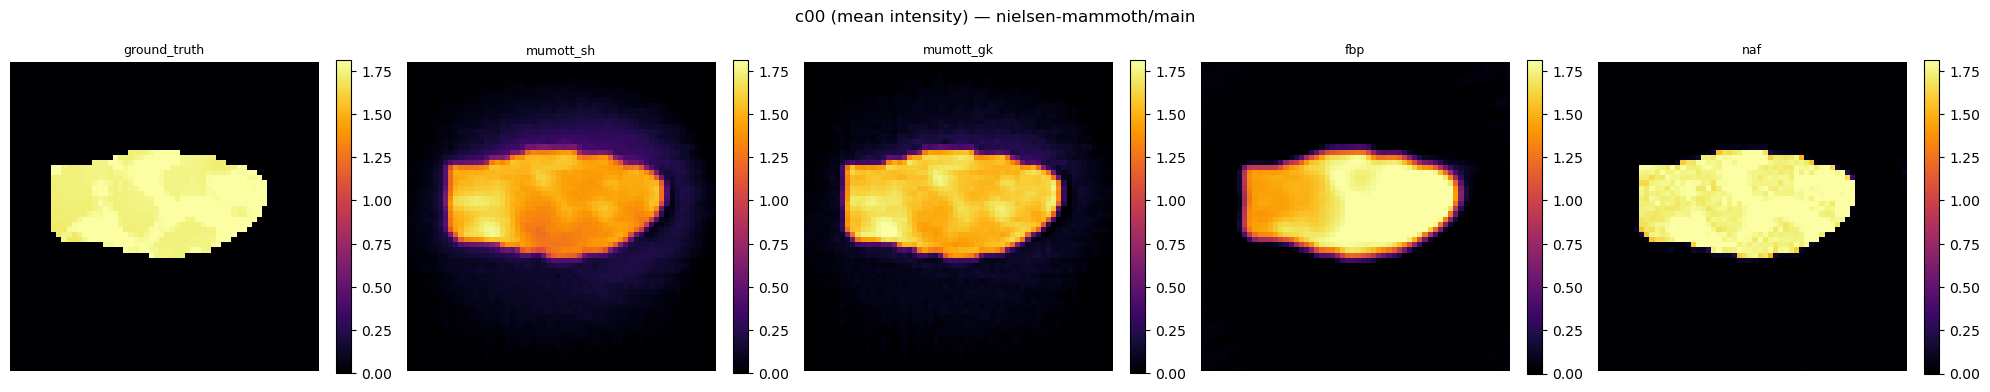

In [13]:
from matplotlib.lines import Line2D

def plot_c00_comparison(coeffs_dict, gt, title, slice_axis='z'):
    methods = list(coeffs_dict.keys())
    n = len(methods) + (1 if gt is not None else 0)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    ref = gt if gt is not None else coeffs_dict[methods[0]]
    lo, hi = np.percentile(ref[..., 0], [2, 98])
    mid = ref.shape[{'x': 0, 'y': 1, 'z': 2}[slice_axis]] // 2
    items = ([('ground_truth', gt)] if gt is not None else []) + list(coeffs_dict.items())
    for ax, (label, c) in zip(axes, items):
        c00 = c[..., 0]
        sl = c00[mid] if slice_axis == 'x' else (c00[:, mid] if slice_axis == 'y' else c00[:, :, mid])
        im = ax.imshow(sl.T, cmap='inferno', vmin=lo, vmax=hi, origin='lower')
        ax.set_title(label, fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

for dc_type in partial_types:
    plot_c00_comparison(
        all_coeffs[dc_type], coeffs_gt,
        title=f'c00 (mean intensity) — {ds.name}/{dc_type}',
    )
    plt.show()

### 7b. Per-voxel RSM correlation maps

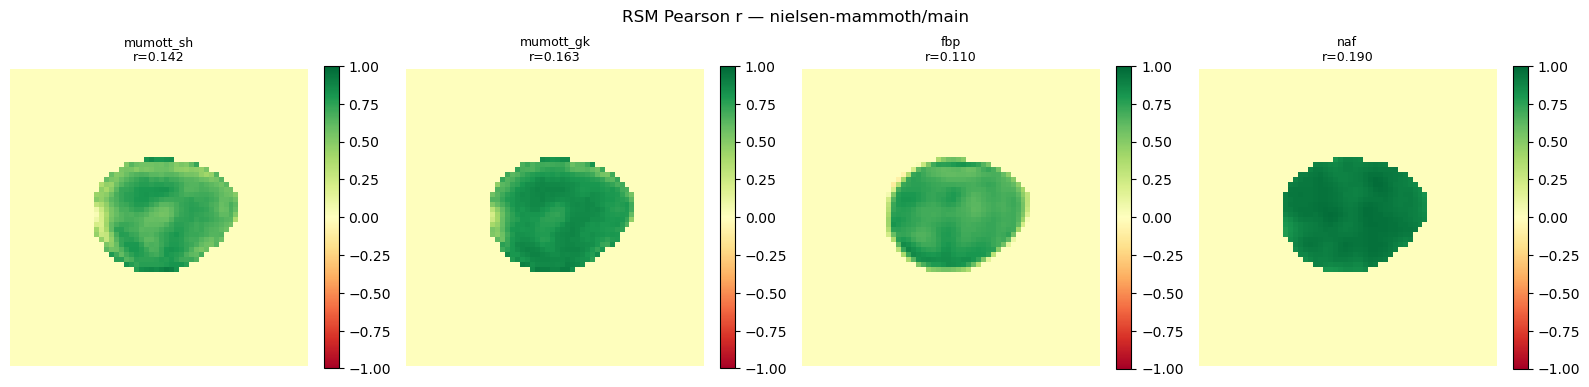

In [26]:
def plot_corr_maps(results, title, mid=None):
    methods = list(results.keys())
    fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4))
    if len(methods) == 1:
        axes = [axes]
    for ax, method in zip(axes, methods):
        cmap = results[method]['rsm_corr_map']
        if mid is None:
            mid  = cmap.shape[2] // 2
        im   = ax.imshow(cmap[:, :, mid].T, cmap='RdYlGn', vmin=-1, vmax=1, origin='lower')
        ax.set_title(f"{method}\nr={results[method]['rsm_corr_mean']:.3f}", fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f'RSM Pearson r — {title}')
    fig.tight_layout()
    return fig

for dc_type in partial_types:
    plot_corr_maps(all_results[dc_type], f'{ds.name}/{dc_type}', mid=50)
    plt.show()

### 7c. Orientation error maps

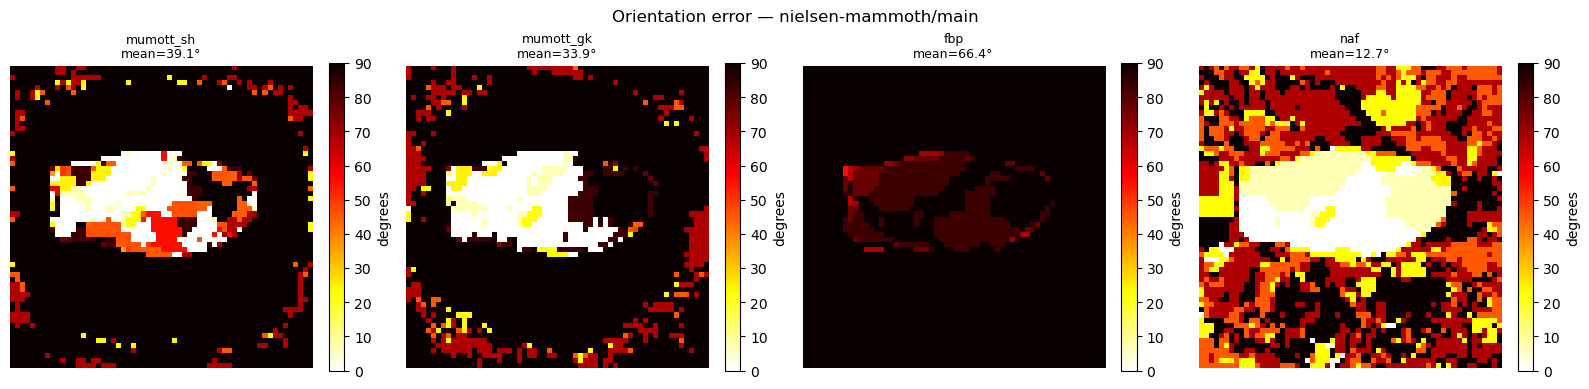

In [15]:
def plot_orientation_maps(results, title):
    methods = [m for m in results if 'orientation_error_map' in results[m]]
    if not methods:
        print('No orientation maps available (compute_orientation=False?)')
        return
    fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4))
    if len(methods) == 1:
        axes = [axes]
    for ax, method in zip(axes, methods):
        err = results[method]['orientation_error_map']
        mid = err.shape[2] // 2
        im  = ax.imshow(err[:, :, mid].T, cmap='hot_r', vmin=0, vmax=90, origin='lower')
        ax.set_title(f"{method}\nmean={results[method]['orientation_error_mean']:.1f}°", fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, label='degrees')
    fig.suptitle(f'Orientation error — {title}')
    fig.tight_layout()
    return fig

for dc_type in partial_types:
    plot_orientation_maps(all_results[dc_type], f'{ds.name}/{dc_type}')
    plt.show()

### 7d. Per-direction RSM volumes (qualitative)
Use `plot_rsm_direction` from `smartt.saxs_naf.eval` to compare a specific
RSM direction across methods.

In [16]:
# !pip install pytest

In [17]:
"""Evaluation for SAXS NAF: per-RSM-direction reconstruction comparison.

Mirrors ``notebooks/saxs_fbp_method_comparison.ipynb``: discretise the sphere
into ``K`` Fibonacci directions, evaluate each model's SH-coefficient field at
those directions to obtain ``(K, X, Y, Z)`` RSM volumes, crop to the inscribed
sphere, and compare per direction.  Works with or without a remounted/full
reference DataContainer.

The SH point-evaluation here uses the **same convention as
``forward_quadrature``** (4π-normalised real SH, Condon-Shortley cancelled), so
it is consistent with the basis the NAF coefficients are optimised in — do NOT
substitute mumott's ``_get_projection_matrix`` for NAF coefficients.
"""

from __future__ import annotations

import math
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch

from smartt.shutils.evaulate_sh import associated_legendre, _generate_lm_list


def evaluate_real_sh(directions: torch.Tensor, ell_max: int) -> torch.Tensor:
    """Real-SH basis matrix ``B[k, c] = Y_c(direction_k)``.

    Parameters
    ----------
    directions : ``(K, 3)`` unit vectors (any float dtype/device).
    ell_max : Maximum even degree.

    Returns
    -------
    ``(K, C)`` tensor in the ``forward_quadrature`` convention.
    """
    directions = directions / directions.norm(dim=-1, keepdim=True).clamp_min(1e-12)
    x, y, z = directions[:, 0], directions[:, 1], directions[:, 2]
    cos_theta = z.clamp(-1.0, 1.0)
    phi = torch.atan2(y, x)

    lm_list = _generate_lm_list(ell_max)
    cols: List[torch.Tensor] = []
    for l, m in lm_list:
        ma = abs(m)
        P = associated_legendre(l, ma, cos_theta)
        two_minus_delta = 1 if ma == 0 else 2
        factor = math.sqrt(
            two_minus_delta * (2 * l + 1)
            * (math.factorial(l - ma) / float(math.factorial(l + ma)))
        )
        cs = (-1.0) ** ma          # cancel Condon-Shortley built into associated_legendre
        if m > 0:
            col = cs * factor * P * torch.cos(ma * phi)
        elif m < 0:
            col = cs * factor * P * torch.sin(ma * phi)
        else:
            col = factor * P
        cols.append(col)
    return torch.stack(cols, dim=-1)   # (K, C)


def coeffs_to_rsm_volumes(
    coeffs: torch.Tensor, directions: np.ndarray, ell_max: int
) -> torch.Tensor:
    """``(X, Y, Z, C)`` coefficients → ``(K, X, Y, Z)`` directional volumes."""
    dirs = torch.from_numpy(directions).float()
    B = evaluate_real_sh(dirs, ell_max)                    # (K, C)
    return torch.einsum("xyzc,kc->kxyz", torch.from_numpy(coeffs).float(), B)


def relative_anisotropy(rsm_volumes: torch.Tensor, sphere_mask=None) -> torch.Tensor:
    """Per-voxel RA = std / mean of the RSM samples over the K directions.

    A robust scalar anisotropy proxy (robust to the missing wedge), computed
    directly from the directional samples rather than the SH tensor.
    """
    mean = rsm_volumes.mean(dim=0)
    std = rsm_volumes.std(dim=0)
    ra = std / mean.clamp_min(1e-8)
    return ra


def evaluate_models(
    models: Dict[str, torch.Tensor],
    *,
    ell_max: int = 8,
    K: int = 30,
    half_space: str = "y",
    alpha_deg: Optional[float] = None,
    goniometer_axis: Optional[np.ndarray] = None,
    cube_size: Optional[int] = None,
) -> Dict:
    """Evaluate several coefficient fields into cropped RSM volumes for comparison.

    Parameters
    ----------
    models : mapping ``name -> (X, Y, Z, C)`` SH-coefficient tensor.  Different
        methods (NAF, direct-GD, mumott-LBFGS, …) keyed by label.
    ell_max, K, half_space : RSM sampling controls.
    alpha_deg, goniometer_axis : if given, annotate each direction with its
        missing-arc (degrees) for wedge-severity bucketing.
    cube_size : inscribed-cube side (multiple of 8); default from volume shape.

    Returns
    -------
    dict with ``y_directions`` ``(K,3)``, ``volumes`` (``name -> (K,d,d,d)``),
    ``sphere_mask`` ``(d,d,d)`` bool, ``cube_size``, and optional
    ``missing_arcs_deg`` ``(K,)``.
    """
    from smartt.saxs_fbp import fibonacci_hemisphere
    from smartt.saxs_isonet.preprocess import spherical_crop

    y_directions = fibonacci_hemisphere(K, half_space=half_space)

    volumes: Dict[str, torch.Tensor] = {}
    sphere_mask = None
    d = None
    for name, coeffs in models.items():
        vols = coeffs_to_rsm_volumes(coeffs, y_directions, ell_max)  # (K,X,Y,Z)
        cropped, sphere_mask, d = spherical_crop(vols.cpu(), cube_size=cube_size)
        # volumes[name] = cropped
        volumes[name] = vols.cpu()

    out = {
        "y_directions": y_directions,
        "volumes": volumes,
        "sphere_mask": sphere_mask,
        "cube_size": d,
    }
    if alpha_deg is not None:
        from smartt.saxs_isonet.wedge import all_missing_arcs

        out["missing_arcs_deg"] = np.degrees(
            all_missing_arcs(y_directions, alpha_deg, goniometer_axis)
        )
    return out


def plot_rsm_direction(result: Dict, k: int, axis: str = "z", slice_index=None):
    """Quick orthogonal-slice comparison of all models for direction ``k``.

    Mirrors the fbp-comparison notebook's per-direction view: one column per
    model, shared colour scale from the reference (first) model's sphere interior.
    """
    import matplotlib.pyplot as plt

    volumes = result["volumes"]
    sphere_mask = result["sphere_mask"]
    names = list(volumes.keys())
    d = result["cube_size"]
    if slice_index is None:
        slice_index = d // 2

    ref = volumes[names[0]][k].numpy()
    lo, hi = np.percentile(ref, [2, 98])
    lo = 0

    fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4), squeeze=False)
    for col, name in enumerate(names):
        vol = volumes[name][k].numpy()
        sl = {"x": vol[slice_index], "y": vol[:, slice_index], "z": vol[:, :, slice_index]}[axis]
        im = axes[0, col].imshow(sl.T, cmap="inferno", vmin=lo, vmax=hi, origin="lower")
        axes[0, col].set_title(name)
        axes[0, col].axis("off")
        plt.colorbar(im, ax=axes[0, col], fraction=0.046)

    ydir = np.round(result["y_directions"][k], 3)
    title = f"RSM direction k={k}  y={ydir}"
    if "missing_arcs_deg" in result:
        title += f"  missing_arc={result['missing_arcs_deg'][k]:.1f}°"
    fig.suptitle(title)
    fig.tight_layout()
    return fig


In [18]:
import lovely_tensors as lt
lt.monkey_patch()


main — missing-arc lengths:
  k= 0  arc=180.0°
  k= 1  arc=66.7°
  k= 2  arc=0.0°
  k= 3  arc=0.0°
  k= 4  arc=176.5°
  k= 5  arc=134.6°
  k= 6  arc=0.0°
  k= 7  arc=0.0°
  k= 8  arc=166.1°
  k= 9  arc=162.7°
  k=10  arc=0.0°
  k=11  arc=0.0°
  k=12  arc=149.6°
  k=13  arc=175.6°
  k=14  arc=0.0°
  k=15  arc=0.0°
  k=16  arc=131.9°
  k=17  arc=179.9°
  k=18  arc=127.0°
  k=19  arc=0.0°
  k=20  arc=125.5°
  k=21  arc=179.0°
  k=22  arc=160.8°
  k=23  arc=108.9°
  k=24  arc=140.9°
  k=25  arc=177.0°
  k=26  arc=175.4°
  k=27  arc=161.9°
  k=28  arc=169.2°
  k=29  arc=179.2°


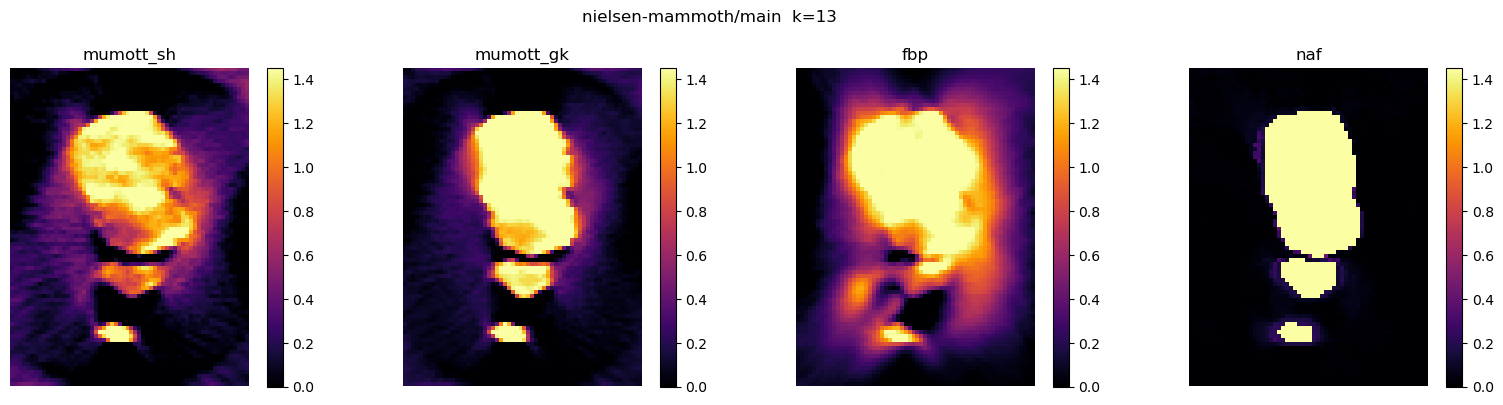

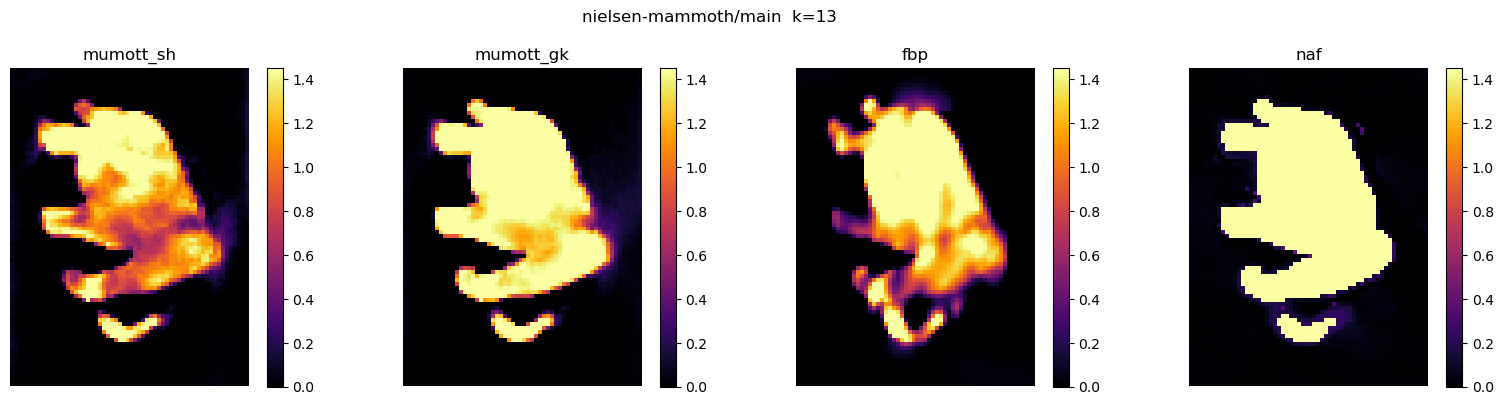

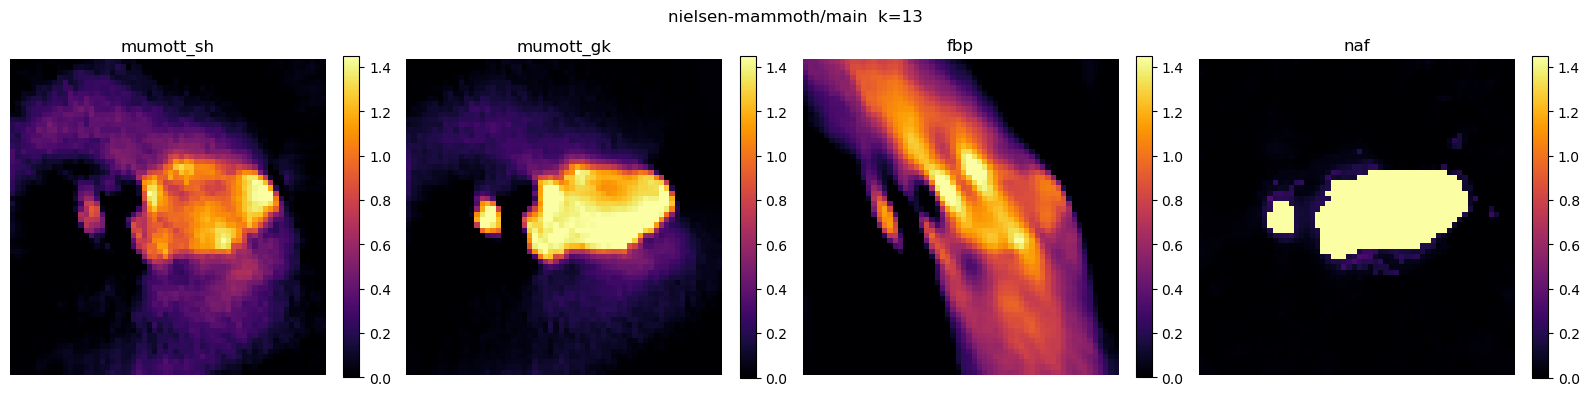

In [19]:
K_SHOW = 13   # direction index — adjust after inspecting missing_arcs_deg below

if coeffs_gt is not None:
    for dc_type in partial_types:
        cmp = evaluate_models(
            {**all_coeffs[dc_type]},
            ell_max=ELL_MAX, K=K_DIRS, half_space=HALF_SPACE,
            alpha_deg=ALPHA_DEG,
        )
        if 'missing_arcs_deg' in cmp:
            print(f'\n{dc_type} — missing-arc lengths:')
            for k, arc in enumerate(cmp['missing_arcs_deg']):
                print(f'  k={k:2d}  arc={arc:.1f}°')
        fig = plot_rsm_direction(cmp, k=K_SHOW, axis='x')
        fig.suptitle(f'{ds.name}/{dc_type}  k={K_SHOW}')
        plt.show()
        fig = plot_rsm_direction(cmp, k=K_SHOW, axis='y')
        fig.suptitle(f'{ds.name}/{dc_type}  k={K_SHOW}')
        plt.show()
        fig = plot_rsm_direction(cmp, k=K_SHOW, axis='z')
        fig.suptitle(f'{ds.name}/{dc_type}  k={K_SHOW}')
        plt.show()

### 7e. Cache inventory

In [20]:
for entry in list_cache(cache_dir):
    print(f"{entry['name']:30s}  hash={entry['hash']}  shape={entry.get('shape')}")

fbp_nielsen-mammoth_main        hash=0f55f1a6  shape=(60, 60, 80, 45)
mumott_gk_nielsen-mammoth_main  hash=9e075eeb  shape=(60, 60, 80, 45)
mumott_sh_nielsen-mammoth_main  hash=dff94c59  shape=(60, 60, 80, 45)
naf_nielsen-mammoth_main        hash=1e7b6234  shape=(60, 60, 80, 45)


## 8. Cross-mounting agreement (NAF main vs remount)

`main` and `remount` are two independent measurements of the **same** sample; the
remount deliberately shifts the missing wedge, which is why `combined ≈ GT`. Here
we reconstruct NAF **separately** on each mounting and ask *how much the two
agree* — a self-consistency validation that needs no ground truth.

**What it does and doesn't prove.** Both reconstructions share the same NAF prior,
so agreement is **necessary but not sufficient** for correctness: they could be
biased the same way and still agree. High agreement is therefore *consistency*
evidence (and disagreement is a clear red flag), not a proof of accuracy. The
strongest reading is per-direction — where `main` lacks coverage that `remount`
actually measures, `remount` acts as a pseudo-GT for `main`'s hallucination.

Metrics reuse §5's `compute_metrics` with one reconstruction as the reference:
- **Symmetric** (`rsm_corr`, orientation error, RA MAE, fiber-symmetry MAE) — the
  two directions should match; a built-in sanity check.
- **Asymmetric** (`NRMSE / PSNR / SSIM`, normalised by the reference) — reported
  both ways (`main→remount`, `remount→main`).

The by-arc table (§8b) buckets agreement by the **nominal** missing-arc severity at
`ALPHA_DEG` (shared goniometer axis — it does *not* model the remount's physical
re-orientation), consistent with §7d.

In [21]:
# 8a. Cross-mounting agreement (NAF main vs remount) — global metrics
from smartt.saxs_naf.metrics import _auto_mask

_has_both = {'main', 'remount'}.issubset(set(partial_types))


def _voxelwise_pearson(a, b):
    """Per-voxel Pearson r between two (K,X,Y,Z) RSM stacks, correlating over K."""
    a0 = a - a.mean(0)
    b0 = b - b.mean(0)
    num = (a0 * b0).sum(0)
    den = np.sqrt((a0 ** 2).sum(0) * (b0 ** 2).sum(0)) + 1e-12
    return num / den


if not _has_both:
    print('Dataset has no main+remount pair — skipping agreement section.')
else:
    naf_main    = all_coeffs['main']['naf']
    naf_remount = all_coeffs['remount']['naf']

    # Shared sample mask (identical in both directions), from the combined GT so
    # it matches the mask used by the §5 metrics.
    common_mask = _auto_mask(coeffs_gt if coeffs_gt is not None else naf_main)

    _agree_kw = dict(ell_max=ELL_MAX, K=K_DIRS, mask=common_mask,
                     half_space=HALF_SPACE, compute_orientation=True)

    # Reuse compute_metrics with one reconstruction acting as the "reference".
    _m2r = compute_metrics(reconstructions={'naf': naf_main}, ground_truth=naf_remount,
                           dc=train_dcs['main'], held_out_dc=held_dcs['main'], **_agree_kw)['naf']
    _r2m = compute_metrics(reconstructions={'naf': naf_remount}, ground_truth=naf_main,
                           dc=train_dcs['remount'], held_out_dc=held_dcs['remount'], **_agree_kw)['naf']

    _SYM  = ['rsm_corr_mean', 'orientation_error_mean', 'ra_mae', 'fiber_symmetry_mae']
    _ASYM = ['nrmse', 'psnr', 'ssim']
    agreement_global = pd.DataFrame(
        {k: {'main→remount': _m2r.get(k), 'remount→main': _r2m.get(k)}
         for k in _SYM + _ASYM}
    ).T
    print('Symmetric metrics (rsm_corr / orientation / ra_mae / fiber_symmetry_mae) '
          'should match in both columns — a sanity check.\n'
          'NRMSE/PSNR/SSIM differ because they are normalised by the reference.')
    display(agreement_global.round(4))


Dataset has no main+remount pair — skipping agreement section.


In [22]:
# 8b. Agreement by missing-arc severity
if _has_both:
    from smartt.saxs_naf.eval import coeffs_to_rsm_volumes
    from smartt.saxs_fbp import fibonacci_hemisphere
    from smartt.saxs_isonet.wedge import all_missing_arcs

    _dirs     = fibonacci_hemisphere(K_DIRS, half_space=HALF_SPACE)
    _rsm_main = coeffs_to_rsm_volumes(naf_main,    _dirs, ELL_MAX).numpy()   # (K,X,Y,Z)
    _rsm_rem  = coeffs_to_rsm_volumes(naf_remount, _dirs, ELL_MAX).numpy()
    _arcs     = np.degrees(all_missing_arcs(_dirs, ALPHA_DEG))               # (K,)

    _buckets = {
        'all':              np.ones(K_DIRS, bool),
        'low (<60°)':       _arcs < 60,
        'medium (60-120°)': (_arcs >= 60) & (_arcs < 120),
        'high (>120°)':     _arcs >= 120,
    }
    _rows = {}
    for _label, _bk in _buckets.items():
        if _bk.sum() >= 2:   # Pearson r needs >= 2 directions
            _cmap = _voxelwise_pearson(_rsm_main[_bk], _rsm_rem[_bk])
            _rows[_label] = {'n_dirs': int(_bk.sum()),
                             'agreement_r': float(_cmap[common_mask].mean())}
    agreement_by_arc = pd.DataFrame(_rows).T
    print('NAF main-vs-remount RSM agreement, bucketed by nominal missing-arc '
          f'severity at ALPHA_DEG={ALPHA_DEG}° (shared goniometer axis, cf. §7d).')
    display(agreement_by_arc.round(4))


In [23]:
# 8c. Agreement maps — where do the two mountings agree / disagree?
if _has_both:
    from smartt.saxs_naf.eval import coeffs_to_rsm_volumes
    from smartt.saxs_fbp import fibonacci_hemisphere

    dirs      = fibonacci_hemisphere(K_DIRS, half_space=HALF_SPACE)
    rsm_main  = coeffs_to_rsm_volumes(naf_main,    dirs, ELL_MAX).numpy()   # (K,X,Y,Z)
    rsm_rem   = coeffs_to_rsm_volumes(naf_remount, dirs, ELL_MAX).numpy()

    agree_map = _voxelwise_pearson(rsm_main, rsm_rem)                       # (X,Y,Z)

    c00_m, c00_r = naf_main[..., 0], naf_remount[..., 0]
    rel_diff = np.abs(c00_m - c00_r) / (0.5 * (np.abs(c00_m) + np.abs(c00_r)) + 1e-8)

    mid = agree_map.shape[2] // 2
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    im0 = axes[0].imshow(np.where(common_mask, agree_map, np.nan)[:, :, mid].T,
                         cmap='RdYlGn', vmin=-1, vmax=1, origin='lower')
    axes[0].set_title(f'RSM agreement r\nmasked mean={float(agree_map[common_mask].mean()):.3f}', fontsize=9)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(np.where(common_mask, rel_diff, np.nan)[:, :, mid].T,
                         cmap='magma', vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'c00 relative |diff|\nmasked mean={float(rel_diff[common_mask].mean()):.3f}', fontsize=9)
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(np.where(common_mask, c00_m, np.nan)[:, :, mid].T,
                         cmap='inferno', origin='lower')
    axes[2].set_title('c00 naf_main (mask)', fontsize=9)
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'{ds.name}  —  NAF main-vs-remount agreement (z-slice {mid})')
    fig.tight_layout()
    plt.show()
